In [ ]:
!pip uninstall transformers -y
!pip install transformers

Found existing installation: transformers 4.52.2
Uninstalling transformers-4.52.2:
  Successfully uninstalled transformers-4.52.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 29.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd

# Define the base directory
nokia_base = "specify"
text_dir = os.path.join(nokia_base, "texts")

# Load each CSV
df_train = pd.read_csv(os.path.join(text_dir, "train.csv"))
df_val = pd.read_csv(os.path.join(text_dir, "val.csv"))
df_test = pd.read_csv(os.path.join(text_dir, "test.csv"))

# Combine them
df = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f"Combined dataset shape: {df.shape}")
df.head()


Combined dataset shape: (10330, 3)


,text,class_id,split
0,NES,a106_address_current_all,train
1,30-0CT-14,a82_date_time,train
2,16,a82_date_time,train
3,30-0CT14,a82_date_time,train
4,9VIF,a82_date_time,train


In [ ]:
def merge_classes_to_location(df):
    df['class_id'] = df['class_id'].replace({
        'a106_address_current_all': 'location',
        'a73_landmark': 'location'
    })
    return df

df = merge_classes_to_location(df)

In [ ]:
df['class_id'].value_counts()

,count
class_id,
a82_date_time,3909
location,3646
a111_name_all,2251
a85_username,234
a49_phone,227
a90_email,63


In [ ]:
df['class_id'] = df['class_id'].replace({'a24_birth_date': 'a82_date_time'})

In [ ]:
df_emails = pd.read_csv(os.path.join(text_dir, "emails.csv"))
df_emails

,text,class_id
0,epatel@126.com,a90_email
1,maria_doe@web.de,a90_email
2,emily.patel@yandex.com,a90_email
3,eali@hotmail.com,a90_email
4,emily.ali@hanmail.net,a90_email
...,...,...
995,anna.brown@yahoo.com,a90_email
996,lucas.brown@126.com,a90_email
997,lee_doe@daum.net,a90_email
998,emily.wang@zoho.com,a90_email


In [ ]:
import random
def distort_email(email):
    variants = []

    if "@" in email:
        variants.append(email.replace("@", ""))
    variants.append(email.replace(".", ","))

    if len(email) > 5:
        i = random.randint(1, len(email) - 2)
        variants.append(email[:i] + email[i+1:])

    return variants

# Sample and augment
augmented_rows = []
sampled = df_emails.sample(n=500, replace=True, random_state=42)

for _, row in sampled.iterrows():
    distortions = distort_email(row["text"])
    distorted = random.choice(distortions)
    augmented_rows.append({
        "text": distorted,
        "class_id": row["class_id"]
    })

df_augmented_500 = pd.DataFrame(augmented_rows)
df_augmented_500

,text,class_id
0,"echen@web,de",a90_email
1,maria.nguyenexample.org,a90_email
2,"apatel@comcast,net",a90_email
3,"nguyen,anna@company,com",a90_email
4,john_brownorange.fr,a90_email
...,...,...
495,"brown,emily@yahoo,co,jp",a90_email
496,"lrodriguez@company,com",a90_email
497,"emily,brown@mail,co,uk",a90_email
498,ahmed.wang@yandexcom,a90_email


In [ ]:
# Take the first 300 rows from the original emails
df_emails_subset = df_emails.iloc[:600].copy()

# Concatenate with the augmented 500 samples
df_combined = pd.concat([df_emails_subset, df_augmented_500], ignore_index=True)

print(df_combined.head())
print(f"Total rows: {len(df_combined)}")


                     text   class_id
0          epatel@126.com  a90_email
1        maria_doe@web.de  a90_email
2  emily.patel@yandex.com  a90_email
3        eali@hotmail.com  a90_email
4   emily.ali@hanmail.net  a90_email
Total rows: 1100


In [ ]:
from sklearn.model_selection import train_test_split

# Shuffle and split the dataset
df_shuffled = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

# Create train-test split
train_df, test_df = train_test_split(df_shuffled, test_size=0.2, random_state=42)

# Assign split labels
train_df["split"] = "train"
test_df["split"] = "test"

# Concatenate back into one dataframe
df_final = pd.concat([train_df, test_df], ignore_index=True)

print(df_final["split"].value_counts())
df_final


split
train    880
test     220
Name: count, dtype: int64


,text,class_id,split
0,john.smith@aol.com,a90_email,train
1,sara.smith@126.com,a90_email,train
2,emily.wang@126.com,a90_email,train
3,ahmed3362@msn.com,a90_email,train
4,john.kim@tutanota.com,a90_email,train
...,...,...,...
1095,emily8339@army.mil,a90_email,test
1096,sara4414@hotmai.com,a90_email,test
1097,emily_brown@qq.com,a90_email,test
1098,"maria2256@orange,fr",a90_email,test


In [ ]:
# Combine original df with new email examples
df = pd.concat([df, df_final], ignore_index=True)

# Shuffle the combined DataFrame
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df['class_id'].value_counts()

,count
class_id,
a82_date_time,3909
location,3646
a111_name_all,2251
a90_email,1163
a85_username,234
a49_phone,227


In [ ]:
# Assume df is your pandas DataFrame
import pandas as pd

# Drop all rows where attr_id is a112_username
df = df[df["class_id"] != "a85_username"]

# Drop rows where attr_id is a14_landmark AND text has less than 4 characters
df = df[~((df["class_id"] == "a73_landmark") & (df["text"].str.len() < 4))]


In [ ]:
import pandas as pd
import random

def generate_phone_number(correct=True):
    if correct:
        formats = [
            "({}) {}-{}",         # (123) 456-7890
            "{}-{}-{}",           # 123-456-7890
            "+1 {} {} {}",        # +1 123 456 7890
            "{}.{}.{}",           # 123.456.7890
            "{} {}",              # 1234567890
        ]
        fmt = random.choice(formats)
        n = [str(random.randint(100, 999)) for _ in range(2)]
        last = str(random.randint(1000, 9999))
        return fmt.format(n[0], n[1], last)
    else:
        # Introduce noise: swap digits, remove spacing, replace with O or l
        base = generate_phone_number(correct=True)
        corrupt = list(base)

        for _ in range(random.randint(1, 3)):
            idx = random.randint(0, len(corrupt) - 1)
            if corrupt[idx].isdigit():
                corrupt[idx] = random.choice(['O', '0', 'l', '', str(random.randint(0, 9))])
            elif corrupt[idx] in ['-', '.', ' ']:
                corrupt[idx] = random.choice(['', ' '])

        return ''.join(corrupt)

# Generate 500 samples: 800 correct, 200 corrupted
data = []
for _ in range(800):
    data.append({"class_id": "a49_phone", "text": generate_phone_number(correct=True)})

for _ in range(200):
    data.append({"class_id": "a49_phone", "text": generate_phone_number(correct=False)})

# Create DataFrame
phone_df = pd.DataFrame(data)

# Optional: Add dummy image_id or location columns if needed later
# phone_df["image_id"] = "placeholder.jpg"

# Preview
print(phone_df.sample(5))


      class_id             text
202  a49_phone     414-722-3445
612  a49_phone     879-481-8732
416  a49_phone  +1 172 161 4345
167  a49_phone  +1 261 499 4071
640  a49_phone     784.402.5869


In [ ]:
phone_df

,class_id,text
0,a49_phone,+1 455 616 4045
1,a49_phone,675-146-5400
2,a49_phone,828-157-2843
3,a49_phone,(902) 454-9872
4,a49_phone,+1 126 324 6198
...,...,...
995,a49_phone,l56-92-2670
996,a49_phone,285-07-2724
997,a49_phone,23241
998,a49_phone,720-88O-1155


In [ ]:
import numpy as np

# Random 80/20 split
phone_df["split"] = np.where(np.random.rand(len(phone_df)) < 0.8, "train", "val")

# Append to your main df
df = pd.concat([df, phone_df], ignore_index=True)


In [ ]:
df

,text,class_id,split
0,CH,a82_date_time,test
1,maria1258@gmx.com,a90_email,test
2,14:40,a82_date_time,val
3,Jinthansoy,location,test
4,TERTON,location,train
...,...,...,...
12191,l56-92-2670,a49_phone,val
12192,285-07-2724,a49_phone,train
12193,23241,a49_phone,train
12194,720-88O-1155,a49_phone,train


In [ ]:
df['class_id'].value_counts()

,count
class_id,
a82_date_time,3909
location,3646
a111_name_all,2251
a49_phone,1227
a90_email,1163


In [ ]:
df_names = pd.read_csv(os.path.join(text_dir, "names.csv"))

# Randomly sample 1500 rows
df_names_sampled = df_names.sample(n=1500, random_state=42).reset_index(drop=True)

# Create 80/20 split column
split_index = int(0.8 * len(df_names_sampled))
df_names_sampled["split"] = ["train"] * split_index + ["test"] * (len(df_names_sampled) - split_index)

# Append to existing df
df = pd.concat([df, df_names_sampled], ignore_index=True)

In [ ]:
df['class_id'].value_counts()

,count
class_id,
a82_date_time,3909
a111_name_all,3751
location,3646
a49_phone,1227
a90_email,1163


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Assuming df is already loaded
# Train = train + val; Test = test
df_trainval = df[df["split"].isin(["train", "val"])]
df_test = df[df["split"] == "test"]

# Features and labels
X_train = df_trainval["text"].astype(str)
y_train = df_trainval["class_id"]

X_test = df_test["text"].astype(str)
y_test = df_test["class_id"]

# Vectorization
vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=10000,
    ngram_range=(1, 2),
    analyzer='char_wb'
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Classifier
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_vec, y_train)

# Evaluation
y_pred = clf.predict(X_test_vec)
print(classification_report(y_test, y_pred))


               precision    recall  f1-score   support

a111_name_all       0.56      0.63      0.59      1081
    a49_phone       0.47      0.87      0.61        82
a82_date_time       0.93      0.84      0.88      1440
    a90_email       0.95      0.96      0.96       253
     location       0.63      0.59      0.61      1353

     accuracy                           0.72      4209
    macro avg       0.71      0.78      0.73      4209
 weighted avg       0.73      0.72      0.72      4209



In [ ]:
!pip install transformers datasets scikit-learn


In [ ]:
!pip install --upgrade transformers


In [ ]:
import transformers
print(transformers.__version__)


4.52.4


## Bert

In [ ]:
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder

# Assume df is your full dataset
df_train = df[df['split'].isin(['train', 'val'])].copy()
df_test = df[df['split'] == 'test'].copy()

# Encode class labels
le = LabelEncoder()
df_train['label'] = le.fit_transform(df_train['class_id'])
df_test['label'] = le.transform(df_test['class_id'])

# Hugging Face Dataset
ds_train = Dataset.from_pandas(df_train[['text', 'label']])
ds_test = Dataset.from_pandas(df_test[['text', 'label']])


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

ds_train = ds_train.map(tokenize, batched=True)
ds_test = ds_test.map(tokenize, batched=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/9487 [00:00<?, ? examples/s]

Map:   0%|          | 0/4209 [00:00<?, ? examples/s]

In [ ]:


from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt
import os

# Load model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(le.classes_))
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Training arguments
args = TrainingArguments(
    output_dir="./bert_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

# Metric computation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

# Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_test,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

# Train and save model
trainer.train()
trainer.save_model("./bert_output/final_model")
tokenizer.save_pretrained("./bert_output/final_model")


In [ ]:
# Run prediction
predictions = trainer.predict(ds_test)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Print classification report
print(classification_report(labels, preds, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(os.path.join(nokia_base, "final_model"))
trainer = Trainer(model=model)

# === Run Prediction ===
predictions = trainer.predict(ds_test)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# === Classification Report ===
print(classification_report(labels, preds, target_names=le.classes_))

# === Confusion Matrix ===
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# # Load tokenizer and model
# tokenizer = AutoTokenizer.from_pretrained("./bert_output/final_model")
# model = AutoModelForSequenceClassification.from_pretrained("./bert_output/final_model")
# model.eval()

# # Load CSV
# df_safe = pd.read_csv("val_safe.csv")

# # Tokenize and predict in batches
# # Ensure all texts are strings and handle potential None/NaN values
# texts = df_safe['text'].dropna().astype(str).tolist() # Drop NaN/None and ensure string type
# batch_size = 64
# to_keep = []

# for i in range(0, len(texts), batch_size):
#     batch_texts = texts[i:i + batch_size]
#     # Explicitly convert each item in the batch to string before tokenizing
#     batch_texts_cleaned = [str(t) for t in batch_texts]
#     encodings = tokenizer(batch_texts_cleaned, padding=True, truncation=True, return_tensors="pt")

#     with torch.no_grad():
#         outputs = model(**encodings)
#         probs = torch.softmax(outputs.logits, dim=-1)
#         max_probs, preds = torch.max(probs, dim=1)

#     # Keep texts with max confidence < 0.7
#     # Use the original batch_texts (which are already cleaned and converted to string)
#     for text, prob in zip(batch_texts, max_probs):
#         if prob.item() < 0.7:
#             to_keep.append(text)

# # Save filtered safes
# df_safe_filtered = pd.DataFrame({'text': to_keep, 'class_id': 'safe'})
# df_safe_filtered.to_csv("val_safe_filtered.csv", index=False)
# print(f"Saved {len(df_safe_filtered)} rows to val_safe_filtered.csv")

In [ ]:
base_dir = "specify"
model_path = os.path.join(base_dir, "final_model")
csv_input = os.path.join(base_dir, "texts", "val_safe.csv")
csv_output = os.path.join(base_dir, "texts", "val_safe_filtered.csv")

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

# Load CSV
df_safe = pd.read_csv(csv_input)

# Tokenize and predict in batches
texts = df_safe['text'].dropna().astype(str).tolist()
batch_size = 64
to_keep = []

for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i + batch_size]
    batch_texts_cleaned = [str(t) for t in batch_texts]
    encodings = tokenizer(batch_texts_cleaned, padding=True, truncation=True, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**encodings)
        probs = torch.softmax(outputs.logits, dim=-1)
        max_probs, _ = torch.max(probs, dim=1)

    for text, prob in zip(batch_texts, max_probs):
        if prob.item() < 0.7:
            to_keep.append(text)

# Save filtered safes
df_safe_filtered = pd.DataFrame({'text': to_keep, 'class_id': 'safe'})
df_safe_filtered.to_csv(csv_output, index=False)
print(f"Saved {len(df_safe_filtered)} rows to {csv_output}")

In [ ]:
df_safe = pd.read_csv("specify")
df_safe

,text,class_id
0,FACE,safe
1,File Edit ew,safe
2,Go Iools Actions Help,safe
3,Search inbox,safe
4,From,safe
...,...,...
3531,COPYRIGHT197475,safe
3532,AYNARD.MASSACHUSETTS,safe
3533,COPYRIGHT O,safe
3534,ROC,safe


In [ ]:
n = int(0.8 * len(df_safe))
df_safe.loc[:n-1, "split"] = "train"
df_safe.loc[n:, "split"] = "test"

In [ ]:
new_df = pd.concat([df, df_safe], ignore_index=True)

print(f"Combined dataset shape: {new_df.shape}")
new_df.tail()

Combined dataset shape: (11646, 3)


,text,class_id,split
11641,COPYRIGHT197475,safe,test
11642,AYNARD.MASSACHUSETTS,safe,test
11643,COPYRIGHT O,safe,test
11644,ROC,safe,test
11645,S,safe,test


# BERT2

In [ ]:
df = new_df.copy()

In [ ]:
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder

# Assume df is your full dataset
df_train = df[df['split'].isin(['train', 'val'])].copy()
df_test = df[df['split'] == 'test'].copy()

# Encode class labels
le = LabelEncoder()
df_train['label'] = le.fit_transform(df_train['class_id'])
df_test['label'] = le.transform(df_test['class_id'])

# Hugging Face Dataset
ds_train = Dataset.from_pandas(df_train[['text', 'label']])
ds_test = Dataset.from_pandas(df_test[['text', 'label']])


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

ds_train = ds_train.map(tokenize, batched=True)
ds_test = ds_test.map(tokenize, batched=True)


Map:   0%|          | 0/8001 [00:00<?, ? examples/s]

Map:   0%|          | 0/3645 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt
import os

# Load model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(le.classes_))
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Training arguments
args = TrainingArguments(
    output_dir="./bert_output2",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

# Metric computation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

# Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_test,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

# Train and save model
trainer.train()
trainer.save_model("./bert_output2/final_model")
tokenizer.save_pretrained("./bert_output2/final_model")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-29-e8ec26164b1f>:34: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.748800,0.723624,0.763237,0.750564
2,0.465900,0.743944,0.782167,0.771989
3,0.316200,0.851814,0.772291,0.763885


('./bert_output2/final_model/tokenizer_config.json',
 './bert_output2/final_model/special_tokens_map.json',
 './bert_output2/final_model/vocab.txt',
 './bert_output2/final_model/added_tokens.json',
 './bert_output2/final_model/tokenizer.json')

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                precision    recall  f1-score   support

 a111_name_all       0.78      0.77      0.77       781
a24_birth_date       0.00      0.00      0.00        30
     a49_phone       0.85      0.73      0.78        82
  a73_landmark       0.73      0.54      0.62       531
 a82_date_time       0.92      0.90      0.91      1410
  a85_username       1.00      0.01      0.03        70
     a90_email       0.88      0.70      0.78        33
          safe       0.61      0.87      0.72       708

      accuracy                           0.78      3645
     macro avg       0.72      0.56      0.58      3645
  weighted avg       0.79      0.78      0.77      3645



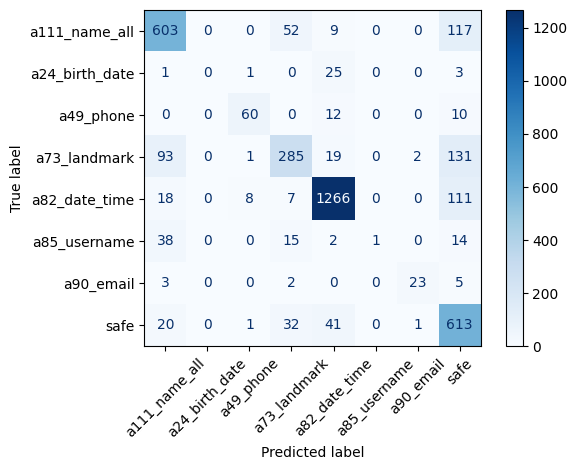

In [ ]:
# Run prediction
predictions = trainer.predict(ds_test)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Print classification report
print(classification_report(labels, preds, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
import shutil
from google.colab import files

# Paths
folder_to_zip = "/content/bert_output2/final_model"
zip_output_path = "/content/final_model.zip"
# Create zip file
shutil.make_archive("/content/final_model", 'zip', folder_to_zip)

# Trigger download
files.download(zip_output_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>